# EV Charging Station Siting

This notebook solves a capacitated facility-location MILP for a **teaching-scale
Chicago case**. It is not a ready-to-build capital plan. The revision makes two
important corrections:

1. `max_coverage` is lexicographic: maximize coverage, then minimize cost, then
   minimize assignment distance. Extra budget can no longer create useless sites.
2. Every input is labelled as **observed source data**, **source-calibrated proxy**,
   or **synthetic model assumption**.

The decision-maker is a municipal planner screening candidate facilities. The
model answers which sites perform best under the stated scenario; engineering,
grid, ownership, equity, and road-network checks remain outside scope.

In [1]:
from pathlib import Path
import os, sys, time, math, platform
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pulp

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent]
            if (p / 'src').exists() and (p / 'data').exists())
sys.path.insert(0, str(ROOT / 'src'))

import data_prep
from model import solve_model, summarize, validate_solution
from plotting import plot_instance, plot_solution

DATA = ROOT / 'data'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 60)
print('project root:', ROOT)

Matplotlib is building the font cache; this may take a moment.


project root: /Users/foury333/Documents/Codex/2026-08-16/du/work/github_ev_charging_siting


## 1. Data provenance: what is real and what is modelled

### Observed source data used directly

- **Candidate locations and facility types:** City of Chicago, [Business Licenses -
  Current Active](https://data.cityofchicago.org/d/uupf-x98q), snapshot 2026-08-16.
  We retain active `Commercial Garage` and `Filling Station` records in the study box.
- **Community boundaries:** City of Chicago, [Boundaries - Community
  Areas](https://data.cityofchicago.org/d/igwz-8jzy), boundary data updated 2025-04-22.
- **Population proxy:** City of Chicago, [ACS 5-Year Data by Community
  Area](https://data.cityofchicago.org/d/t68z-cikk), based on the 2023 ACS.

### Source-calibrated but not observed site values

- The cost envelope is compared with U.S. DOE Alternative Fuels Data Center
  [equipment and installation cost guidance](https://afdc.energy.gov/fuels/electricity-infrastructure-development).
  Our individual site costs are still hypothetical; they are not vendor bids.

### Synthetic model assumptions

- ACS population density determines the *relative spatial pattern*, but the total is
  rescaled to 23,248 demand units. These are not observed EV sessions or vehicles/day.
- Site cost declines with distance from the Loop; that gradient is hypothetical.
- Capacity is 4,000 model units for a garage and 2,200 for a filling station. It is not
  verified charger throughput and therefore receives the strongest stress test.
- Candidate sampling, five-kilometre radius, and straight-line distance are modelling
  choices. A business license proves location/type, not EV readiness or grid capacity.

In [2]:
raw_licenses = pd.read_csv(DATA / 'chicago_candidate_licenses_snapshot.csv')
sites, demands, D = data_prep.build_all(DATA)

provenance = pd.DataFrame([
    ['Candidate coordinates/type', 'Observed source data',
     '553 City license rows -> deterministic 20-site sample'],
    ['Demand spatial pattern', 'Source-calibrated proxy',
     '2023 ACS community population density'],
    ['Total demand', 'Synthetic scale', f'{demands.weight.sum():,} model units'],
    ['Construction cost', 'Synthetic/site scenario', '$60k-$210k distance-based proxy'],
    ['Capacity', 'Synthetic/site scenario', '4,000 garage; 2,200 filling station'],
    ['Distance', 'Calculated from real coordinates', 'Haversine, not road travel time'],
], columns=['Input', 'Status', 'Meaning'])
display(provenance)
print(f'candidate source rows: {len(raw_licenses):,}; selected sites: {len(sites)}')
print(f'grid cells retained after clipping to official City boundary: {len(demands)}')

,Input,Status,Meaning
0,Candidate coordinates/type,Observed source data,553 City license rows -> deterministic 20-site sample
1,Demand spatial pattern,Source-calibrated proxy,2023 ACS community population density
2,Total demand,Synthetic scale,"23,248 model units"
3,Construction cost,Synthetic/site scenario,$60k-$210k distance-based proxy
4,Capacity,Synthetic/site scenario,"4,000 garage; 2,200 filling station"
5,Distance,Calculated from real coordinates,"Haversine, not road travel time"


candidate source rows: 553; selected sites: 20
grid cells retained after clipping to official City boundary: 45


,site_id,name,address,source_type,source_license_number,cost,capacity
0,S00,MCCORMICK PLACE-LAKESIDE CENTER GARGE,2301 S LAKE SHORE DR,Commercial Garage,1621112,132000,4000
1,S01,CERMAK BP,1602 W CERMAK RD,Filling Station,1593164,120000,2200
2,S02,Standard Parking,2150 S CANALPORT AVE,Commercial Garage,2900653,133000,4000
3,S03,MOUNT SINAI HOSPITAL MEDICAL CENTER,2705 W 15TH ST,Commercial Garage,1847238,103000,4000
4,S04,GOLO,3731 W ROOSEVELT RD,Filling Station,1245774,88000,2200
5,S05,BP,50 W IDA B WELLS DR 1,Filling Station,3036721,201000,2200
6,S06,INTERPARK,318 S FEDERAL ST ENCLO,Commercial Garage,22219,208000,4000
7,S07,FAMOUS PARKING LLC,1850-1856 W WALNUT ST,Commercial Garage,3031656,125000,4000
8,S08,Flatiron LLC,504 N GREEN ST,Commercial Garage,2781007,153000,4000
9,S09,ABM INDUSTRIES GROUP LLC,600 E GRAND AVE 1,Commercial Garage,2677481,153000,4000


,demand_id,community_area,acs_population,weight
0,D00,NORTH LAWNDALE,30355.0,283
1,D01,NORTH LAWNDALE,30355.0,283
2,D02,LOWER WEST SIDE,34177.0,349
3,D03,LOWER WEST SIDE,34177.0,349
4,D04,LOWER WEST SIDE,34177.0,349
5,D05,LOWER WEST SIDE,34177.0,349
6,D06,NEAR SOUTH SIDE,26307.0,440
7,D08,EAST GARFIELD PARK,19855.0,307
8,D09,EAST GARFIELD PARK,19855.0,307
9,D10,NEAR WEST SIDE,65370.0,344


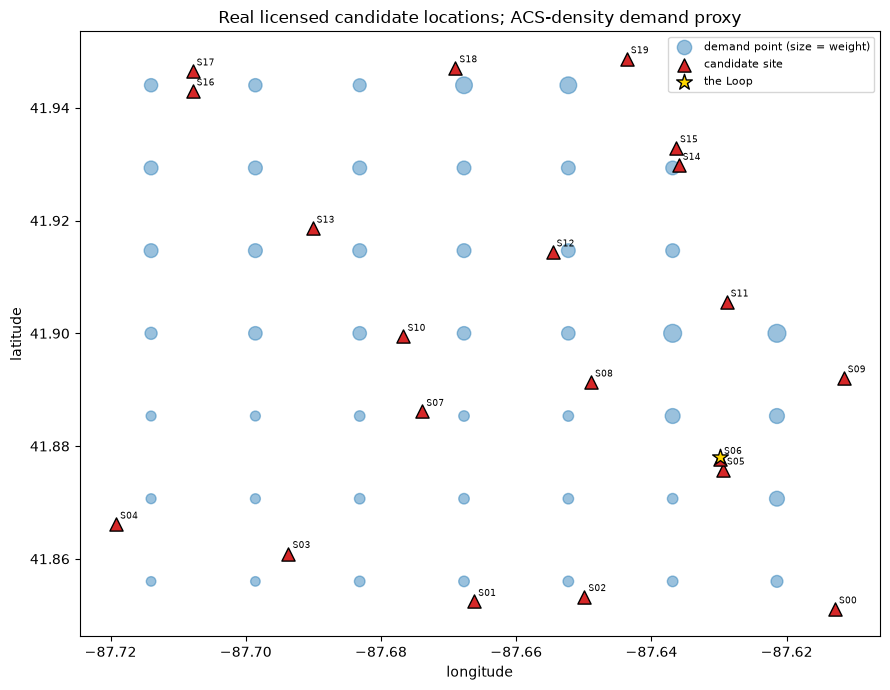

In [3]:
display(sites[['site_id','name','address','source_type','source_license_number',
               'cost','capacity']])
display(demands[['demand_id','community_area','acs_population','weight']].head(10))

ax = plot_instance(sites, demands)
ax.set_title('Real licensed candidate locations; ACS-density demand proxy')
plt.tight_layout()
plt.savefig(FIGURES / 'revised_instance.png', dpi=180)
plt.show()

## 2. Model formulation

Decision variables:

- $y_j\in\{0,1\}$: build at candidate site $j$.
- $x_{ij}\in[0,1]$: fraction of demand unit $i$ assigned to site $j$.

Constraints enforce demand balance (or partial service in coverage mode), linking,
site capacity, construction budget, and the service radius.

The two operational modes are lexicographic:

- **`min_cost`:** serve all demand; minimize construction cost; then minimize
  demand-weighted assignment distance among minimum-cost plans.
- **`max_coverage`:** maximize served demand; then minimize construction cost at that
  coverage; then minimize assignment distance. This avoids arbitrary above-knee spend.

An optional `weighted_cost` mode retains the original $cost+\lambda\,distance$ objective
only for an explicit trade-off analysis; it does not define the minimum-cost knee.

## 3. Baseline solution and feasibility verification

In [4]:
BUDGET, RADIUS = 1_200_000, 5.0
t0 = time.perf_counter()
baseline = solve_model(sites, demands, D, BUDGET, RADIUS, mode='min_cost')
elapsed = time.perf_counter() - t0
summarize(baseline, sites, label='baseline')
print(f'wall-clock for two lexicographic phases: {elapsed:.2f} s')
display(pd.DataFrame(baseline['phases']))
display(sites.iloc[baseline['built']][
    ['site_id','name','address','source_type','cost','capacity']])

[baseline] status: Optimal
  stations built   : 6 of 20
  construction cost: $589,000
  demand covered   : 23,248 (100.0%)
  avg straight-line assignment distance: 2.28 km
  primary objective: 589,000.00
wall-clock for two lexicographic phases: 1.29 s


,phase,status,objective
0,minimize construction cost,Optimal,589000.000000
1,minimize distance at minimum cost,Optimal,52921.336873


,site_id,name,address,source_type,cost,capacity
0,S00,MCCORMICK PLACE-LAKESIDE CENTER GARGE,2301 S LAKE SHORE DR,Commercial Garage,132000,4000
3,S03,MOUNT SINAI HOSPITAL MEDICAL CENTER,2705 W 15TH ST,Commercial Garage,103000,4000
13,S13,MILWAUKEE AVENUE PARKING LLC,2053-2075 N MILWAUKEE AVE,Commercial Garage,94000,4000
15,S15,PIONEER PARKING INC,2800 N LAKE SHORE DR 1-3,Commercial Garage,99000,4000
16,S16,THE LOCK UP/KEDZIE,3366 N KEDZIE AVE 1ST,Commercial Garage,77000,4000
18,S18,ASHLAND ADDISON SHELL,3600 N ASHLAND AVE,Commercial Garage,84000,4000


In [5]:
residuals = validate_solution(
    baseline, sites, demands, D, BUDGET, RADIUS, require_full=True
)
display(pd.Series(residuals, name='maximum violation'))
assert baseline['status'] == 'Optimal'
assert max(residuals.values()) < 1e-4
print('All budget, assignment, capacity, radius, and full-service checks passed.')
print('Solver statement: CBC returned Optimal under its configured tolerances;')
print('the notebook does not claim an independently measured 0.0% MIP gap.')

budget_excess             0.000000e+00
assignment_excess         0.000000e+00
full_service_shortfall    4.000000e-09
capacity_excess           1.250000e-06
radius_excess_km          0.000000e+00
Name: maximum violation, dtype: float64

All budget, assignment, capacity, radius, and full-service checks passed.
Solver statement: CBC returned Optimal under its configured tolerances;
the notebook does not claim an independently measured 0.0% MIP gap.


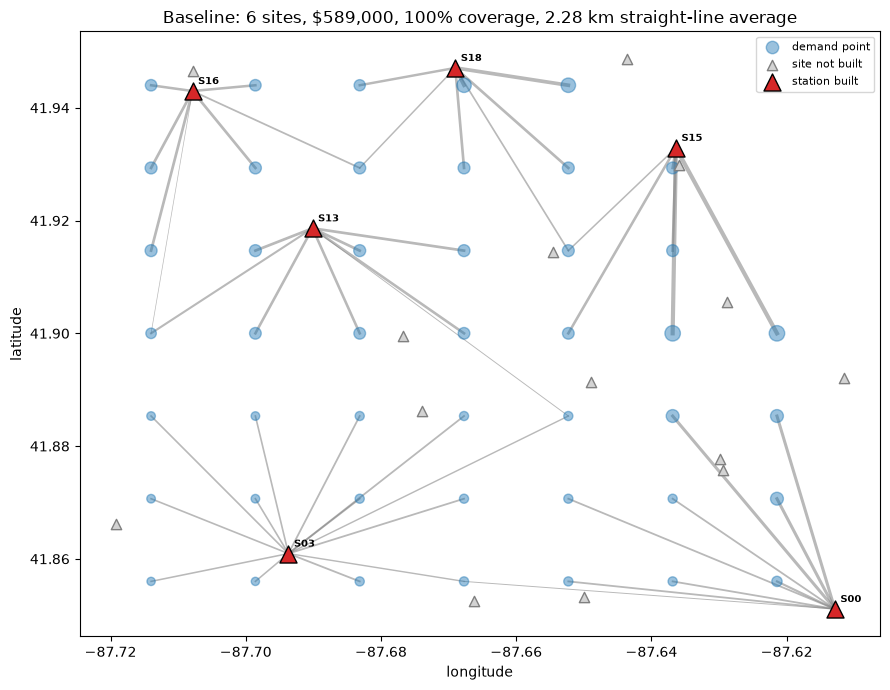

In [6]:
ax = plot_solution(baseline, sites, demands, annotate=True,
    title=(f'Baseline: {len(baseline["built"])} sites, '
           f'${baseline["total_cost"]:,.0f}, 100% coverage, '
           f'{baseline["avg_distance"]:.2f} km straight-line average'))
plt.tight_layout()
plt.savefig(FIGURES / 'revised_baseline.png', dpi=180)
plt.show()

## 4. Two modes answer different budget questions

In [7]:
rows = []
for budget in [300_000, 500_000, 589_000, 650_000, 1_000_000]:
    for mode in ['min_cost', 'max_coverage']:
        result = solve_model(sites, demands, D, budget, RADIUS, mode=mode)
        rows.append({
            'budget': budget, 'mode': mode, 'status': result['status'],
            'sites': len(result['built']), 'spent': result['total_cost'],
            'coverage_pct': result['coverage_pct'],
            'avg_distance_km': result['avg_distance'],
        })
mode_comparison = pd.DataFrame(rows)
display(mode_comparison)

,budget,mode,status,sites,spent,coverage_pct,avg_distance_km
0,300000,min_cost,Infeasible,0,NaN,0.000000,NaN
1,300000,max_coverage,Optimal,3,255000.0,51.617343,1.899511
2,500000,min_cost,Infeasible,0,NaN,0.000000,NaN
3,500000,max_coverage,Optimal,5,457000.0,86.028906,2.254198
4,589000,min_cost,Optimal,6,589000.0,100.000000,2.276382
5,589000,max_coverage,Optimal,6,589000.0,100.000000,2.276382
6,650000,min_cost,Optimal,6,589000.0,100.000000,2.276382
7,650000,max_coverage,Optimal,6,589000.0,100.000000,2.276382
8,1000000,min_cost,Optimal,6,589000.0,100.000000,2.276382
9,1000000,max_coverage,Optimal,6,589000.0,100.000000,2.276382


Below the full-service threshold, `min_cost` is infeasible because it requires every
demand unit to be served; `max_coverage` still provides a best partial plan. At and
above the threshold, both modes use the same minimum-cost plan. In particular, a
\$1.0M available budget no longer causes \$951k of arbitrary spend: the lexicographic
tie-break leaves the unused budget unspent.

## 5. Budget sensitivity: coverage saturates, spend does not inflate

In [8]:
budgets = np.arange(150_000, 1_000_001, 50_000)
budget_rows = []
for budget in budgets:
    result = solve_model(sites, demands, D, budget, RADIUS, mode='max_coverage')
    budget_rows.append({
        'budget': budget, 'coverage_pct': result['coverage_pct'],
        'spent': result['total_cost'], 'sites': len(result['built']),
        'avg_distance_km': result['avg_distance'],
    })
budget_sweep = pd.DataFrame(budget_rows)
knee_result = solve_model(sites, demands, D, 3_000_000, RADIUS, mode='min_cost')
knee = int(knee_result['total_cost'])
print(f'exact minimum construction cost for full coverage: ${knee:,}')
display(budget_sweep)

exact minimum construction cost for full coverage: $589,000


,budget,coverage_pct,spent,sites,avg_distance_km
0,150000,17.205781,77000.0,1,1.791574
1,200000,34.411562,161000.0,2,1.802291
2,250000,49.290261,247000.0,3,2.433476
3,300000,51.617343,255000.0,3,1.899511
4,350000,66.496043,341000.0,4,2.770456
5,400000,68.823125,354000.0,4,2.248512
6,450000,83.701824,444000.0,5,2.702916
7,500000,86.028906,457000.0,5,2.254198
8,550000,95.147970,549000.0,6,2.621282
9,600000,100.000000,589000.0,6,2.276382


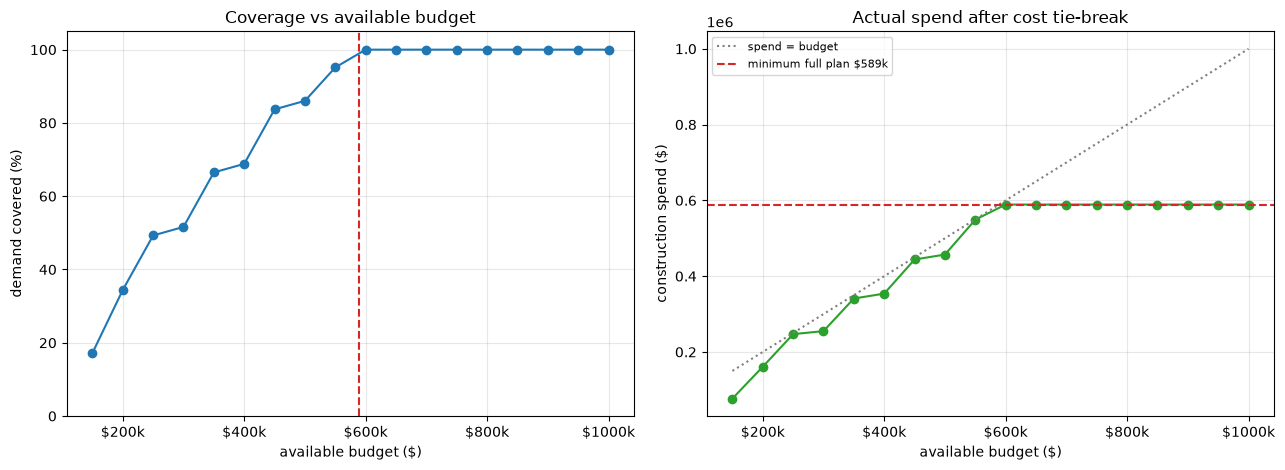

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(budget_sweep.budget, budget_sweep.coverage_pct, marker='o')
axes[0].axvline(knee, color='tab:red', ls='--')
axes[0].set(title='Coverage vs available budget', xlabel='available budget ($)',
            ylabel='demand covered (%)', ylim=(0,105))
axes[1].plot(budget_sweep.budget, budget_sweep.spent, marker='o', color='tab:green')
axes[1].plot(budget_sweep.budget, budget_sweep.budget, ls=':', color='grey', label='spend = budget')
axes[1].axhline(knee, color='tab:red', ls='--', label=f'minimum full plan ${knee/1000:.0f}k')
axes[1].set(title='Actual spend after cost tie-break', xlabel='available budget ($)',
            ylabel='construction spend ($)')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=.3)
    ax.xaxis.set_major_formatter(lambda v, p: f'${v/1000:.0f}k')
plt.tight_layout()
plt.savefig(FIGURES / 'revised_budget_sweep.png', dpi=180)
plt.show()

## 6. Service-radius sensitivity: compute the actual floor

In [10]:
nearest = D.min(axis=1)
limiting_i = int(nearest.argmax())
geometric_floor = float(nearest[limiting_i])
print(f'geometric lower bound: {geometric_floor:.3f} km')
display(demands.iloc[[limiting_i]][['demand_id','community_area','lon','lat','weight']])

radii = [2.0, 2.5, 2.85, 2.86, 2.863, 2.9, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0]
radius_rows = []
for radius in radii:
    result = solve_model(sites, demands, D, 3_000_000, radius, mode='min_cost')
    radius_rows.append({
        'radius_km': radius, 'status': result['status'],
        'sites': len(result['built']), 'cost': result['total_cost'],
        'avg_distance_km': result['avg_distance'],
    })
radius_sweep = pd.DataFrame(radius_rows)
display(radius_sweep)

geometric lower bound: 2.863 km


,demand_id,community_area,lon,lat,weight
21,D24,HUMBOLDT PARK,-87.714,41.9,456


,radius_km,status,sites,cost,avg_distance_km
0,2.000,Infeasible,0,NaN,NaN
1,2.500,Infeasible,0,NaN,NaN
2,2.850,Infeasible,0,NaN,NaN
3,2.860,Infeasible,0,NaN,NaN
4,2.863,Optimal,8,868000.0,1.525263
5,2.900,Optimal,8,868000.0,1.525263
6,3.000,Optimal,7,839000.0,1.718016
7,3.500,Optimal,6,681000.0,1.809345
8,4.000,Optimal,6,627000.0,1.907099
9,5.000,Optimal,6,589000.0,2.276382


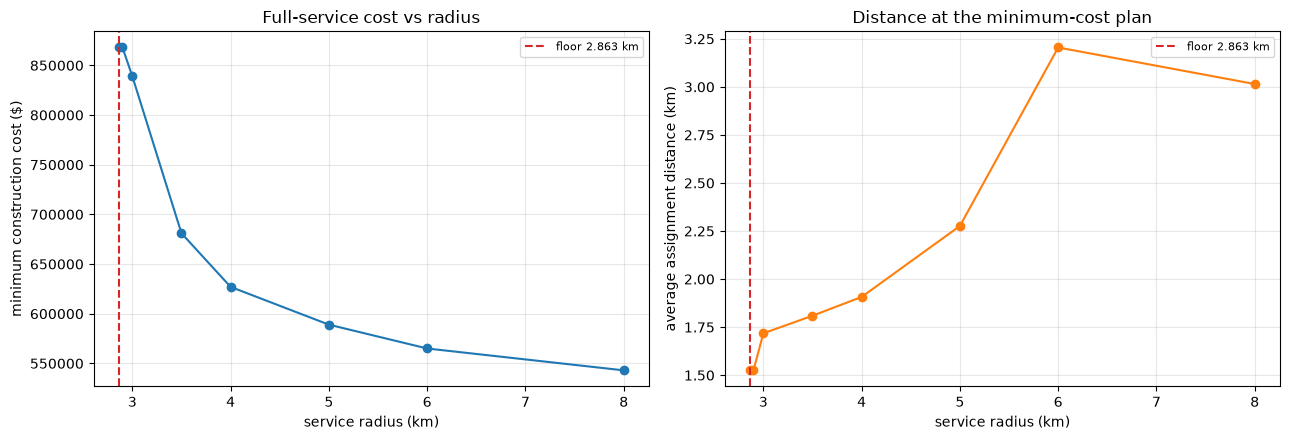

In [11]:
feasible_radius = radius_sweep[radius_sweep.status == 'Optimal']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(feasible_radius.radius_km, feasible_radius.cost, marker='o')
axes[0].set(xlabel='service radius (km)', ylabel='minimum construction cost ($)',
            title='Full-service cost vs radius')
axes[1].plot(feasible_radius.radius_km, feasible_radius.avg_distance_km,
             marker='o', color='tab:orange')
axes[1].set(xlabel='service radius (km)', ylabel='average assignment distance (km)',
            title='Distance at the minimum-cost plan')
for ax in axes:
    ax.axvline(geometric_floor, color='tab:red', ls='--', label=f'floor {geometric_floor:.3f} km')
    ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'revised_radius_sweep.png', dpi=180)
plt.show()

The correct statement is not “below 4 km is infeasible.” With the source-based
candidate set, the limiting point is 2.863 km from its nearest candidate: 2.860 km is
infeasible and 2.863 km is feasible. The threshold is a property of the candidate
network, not the construction budget.

## 7. Capacity sensitivity: a lower bound, not an identity

In [12]:
capacity_rows = []
for scale in [0.5, 0.6, 0.75, 1.0, 1.25, 1.5]:
    result = solve_model(sites, demands, D, 3_000_000, RADIUS,
                         mode='min_cost', capacity_scale=scale)
    lower_bound = math.ceil(demands.weight.sum() / (sites.capacity.max() * scale))
    capacity_rows.append({
        'capacity_scale': scale, 'status': result['status'],
        'sites_built': len(result['built']), 'capacity_lower_bound': lower_bound,
        'cost': result['total_cost'],
    })
capacity_sweep = pd.DataFrame(capacity_rows)
display(capacity_sweep)

,capacity_scale,status,sites_built,capacity_lower_bound,cost
0,0.50,Optimal,13,12,1314000.0
1,0.60,Optimal,10,10,1048000.0
2,0.75,Optimal,8,8,790000.0
3,1.00,Optimal,6,6,589000.0
4,1.25,Optimal,5,5,495000.0
5,1.50,Optimal,4,4,417000.0


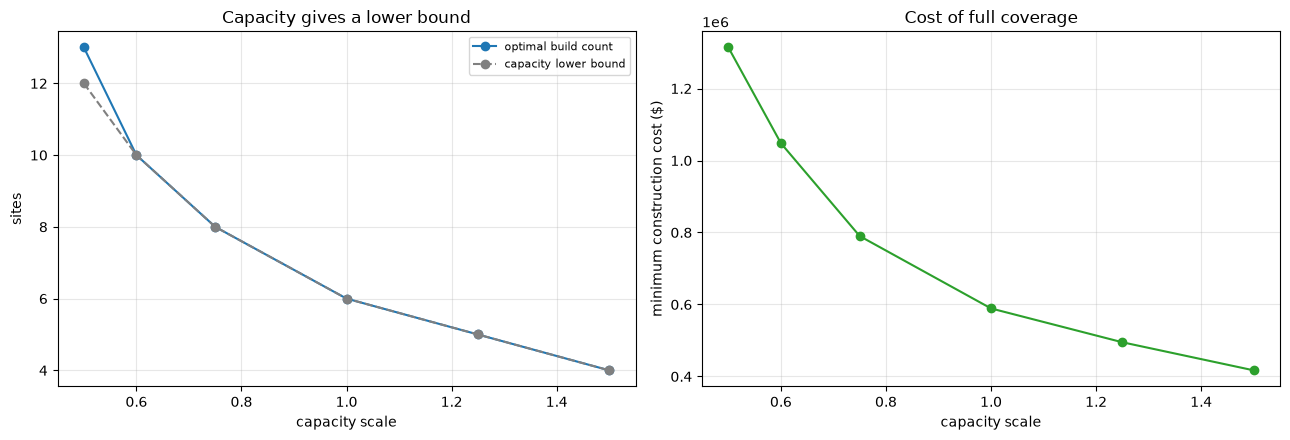

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(capacity_sweep.capacity_scale, capacity_sweep.sites_built,
             marker='o', label='optimal build count')
axes[0].plot(capacity_sweep.capacity_scale, capacity_sweep.capacity_lower_bound,
             marker='o', ls='--', color='grey', label='capacity lower bound')
axes[0].set(xlabel='capacity scale', ylabel='sites', title='Capacity gives a lower bound')
axes[0].legend(fontsize=8)
axes[1].plot(capacity_sweep.capacity_scale, capacity_sweep.cost,
             marker='o', color='tab:green')
axes[1].set(xlabel='capacity scale', ylabel='minimum construction cost ($)',
            title='Cost of full coverage')
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIGURES / 'revised_capacity_sweep.png', dpi=180)
plt.show()

At the 0.5 capacity scale, the arithmetic lower bound is 12 sites but the spatially
feasible optimum needs 13. Capacity strongly drives the answer, but geography can force
additional sites; “how many is only arithmetic” was too strong.

## 8. Optional travel-cost trade-off

In [14]:
lambda_rows = []
for lam in [0, 0.5, 1, 2, 5, 10, 25, 50, 100]:
    result = solve_model(sites, demands, D, BUDGET, RADIUS,
                         lam=lam, mode='weighted_cost')
    lambda_rows.append({'lambda': lam, 'sites': len(result['built']),
                        'construction_cost': result['total_cost'],
                        'avg_distance_km': result['avg_distance']})
lambda_sweep = pd.DataFrame(lambda_rows)
display(lambda_sweep)

,lambda,sites,construction_cost,avg_distance_km
0,0.0,6,589000.0,3.301590
1,0.5,6,589000.0,2.276382
2,1.0,6,590000.0,2.208570
3,2.0,6,590000.0,2.208570
4,5.0,6,606000.0,2.019153
5,10.0,6,627000.0,1.904566
6,25.0,7,742000.0,1.609563
7,50.0,8,932000.0,1.394272
8,100.0,10,1167000.0,1.253553


This is an explicitly different policy objective. At $\lambda=0$, assignment distance
is not optimized and is degenerate. The baseline recommendation therefore uses the
lexicographic `min_cost` mode, not an arbitrary composite objective.

## 9. Scenario map: distinguish zero, partial, and full service

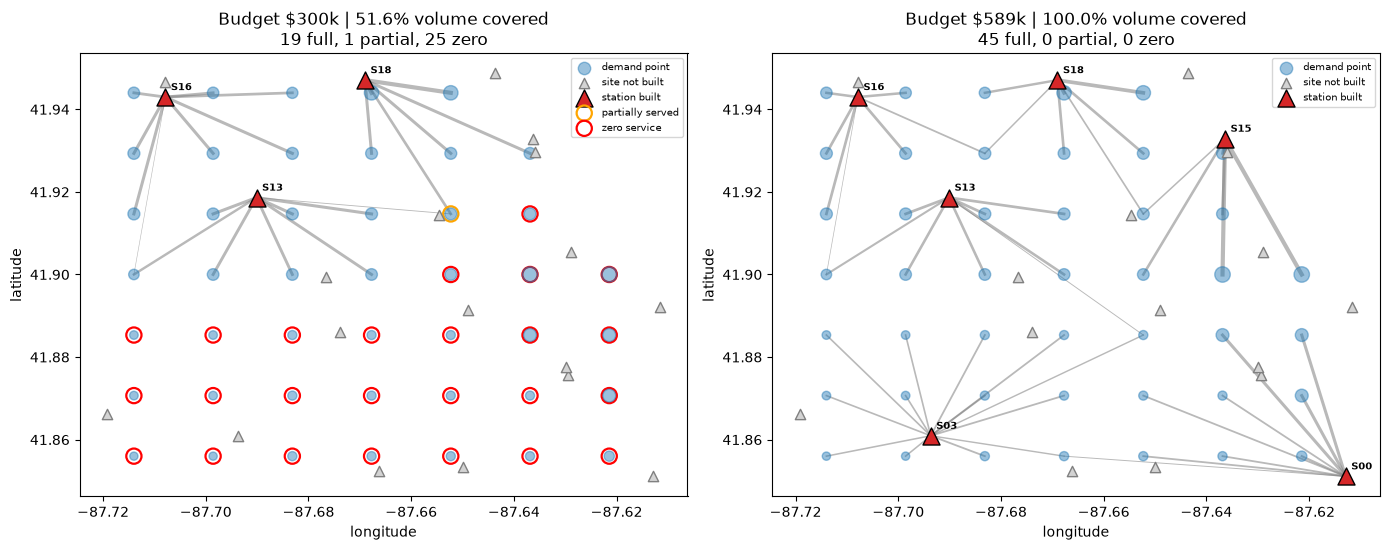

In [15]:
LOW, HIGH = 300_000, knee
low = solve_model(sites, demands, D, LOW, RADIUS, mode='max_coverage')
high = solve_model(sites, demands, D, HIGH, RADIUS, mode='max_coverage')

def service_classes(result):
    served = np.zeros(len(demands))
    for (i, j), value in result['assign'].items(): served[i] += value
    return served, {
        'zero': int((served < 1e-6).sum()),
        'partial': int(((served >= 1e-6) & (served < 0.999999)).sum()),
        'full': int((served >= 0.999999).sum()),
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for result, budget, ax in [(low, LOW, axes[0]), (high, HIGH, axes[1])]:
    served, counts = service_classes(result)
    plot_solution(result, sites, demands, ax=ax, annotate=True,
        title=(f'Budget ${budget/1000:.0f}k | {result["coverage_pct"]:.1f}% volume covered\n'
               f'{counts["full"]} full, {counts["partial"]} partial, {counts["zero"]} zero'))
    partial = demands[(served >= 1e-6) & (served < .999999)]
    zero = demands[served < 1e-6]
    if len(partial): ax.scatter(partial.lon, partial.lat, s=120, facecolors='none',
                                edgecolors='orange', lw=1.6, label='partially served')
    if len(zero): ax.scatter(zero.lon, zero.lat, s=120, facecolors='none',
                             edgecolors='red', lw=1.6, label='zero service')
    ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES / 'revised_budget_comparison.png', dpi=180)
plt.show()

## 10. Robustness: balance scenario families and remove degenerate builds

In [16]:
families = {
    'budget': [(b, solve_model(sites, demands, D, b, RADIUS, mode='max_coverage'))
               for b in [300_000, 400_000, 500_000, knee, 800_000]],
    'radius': [(r, solve_model(sites, demands, D, 3_000_000, r, mode='min_cost'))
               for r in [3.0, 3.5, 4.0, 5.0, 6.0, 8.0]],
    'capacity': [(s, solve_model(sites, demands, D, 3_000_000, RADIUS,
                                 mode='min_cost', capacity_scale=s))
                 for s in [0.5, 0.75, 1.0, 1.25, 1.5]],
}

records = []
for family, scenarios in families.items():
    valid = [result for _, result in scenarios if result['status'] == 'Optimal']
    for site_idx in range(len(sites)):
        records.append({
            'family': family, 'site_id': sites.site_id.iloc[site_idx],
            'frequency': np.mean([site_idx in result['built'] for result in valid]),
        })
family_frequency = pd.DataFrame(records)
robust = (family_frequency.groupby('site_id').frequency.mean()
          .rename('equal_family_score').reset_index()
          .merge(sites[['site_id','name','address','cost','capacity']], on='site_id')
          .sort_values('equal_family_score', ascending=False))
display(robust.head(10))

,site_id,equal_family_score,name,address,cost,capacity
16,S16,1.000000,THE LOCK UP/KEDZIE,3366 N KEDZIE AVE 1ST,77000,4000
18,S18,0.944444,ASHLAND ADDISON SHELL,3600 N ASHLAND AVE,84000,4000
13,S13,0.866667,MILWAUKEE AVENUE PARKING LLC,2053-2075 N MILWAUKEE AVE,94000,4000
3,S03,0.755556,MOUNT SINAI HOSPITAL MEDICAL CENTER,2705 W 15TH ST,103000,4000
15,S15,0.755556,PIONEER PARKING INC,2800 N LAKE SHORE DR 1-3,99000,4000
0,S00,0.455556,MCCORMICK PLACE-LAKESIDE CENTER GARGE,2301 S LAKE SHORE DR,132000,4000
19,S19,0.244444,PIONEER PARKING INC,"3600 N LAKE SHORE DR BSMT, 1, 2, 3",86000,4000
12,S12,0.188889,IMPARK,1840 N CLYBOURN AVE,115000,4000
7,S07,0.122222,FAMOUS PARKING LLC,1850-1856 W WALNUT ST,125000,4000
8,S08,0.122222,Flatiron LLC,504 N GREEN ST,153000,4000


The score gives the budget, radius, and capacity families equal weight. It is a
scenario-stability diagnostic, not a probability. “Commit these sites first” should be
treated as provisional until grid feasibility, ownership, road travel, existing chargers,
and equity constraints are added.

## 11. Repeatable decision-support function

In [17]:
def recommend(budget, radius=5.0, show_map=False):
    result = solve_model(sites, demands, D, budget, radius, mode='min_cost')
    mode = 'min_cost'
    if result['status'] != 'Optimal':
        result = solve_model(sites, demands, D, budget, radius, mode='max_coverage')
        mode = 'max_coverage'
    if result['status'] != 'Optimal':
        return {'status': result['status'], 'message': 'No feasible candidate connection.'}
    served, counts = service_classes(result)
    summary = {
        'mode': mode, 'available_budget': budget, 'spent': result['total_cost'],
        'unused_budget': budget - result['total_cost'],
        'coverage_pct': result['coverage_pct'], 'sites': list(sites.site_id.iloc[result['built']]),
        **{f'{key}_demand_points': value for key, value in counts.items()},
        'scope_warning': 'Illustrative plan; costs/capacities are scenario assumptions.',
    }
    if show_map:
        plot_solution(result, sites, demands, annotate=True)
        plt.show()
    return summary

display(pd.DataFrame([recommend(300_000), recommend(knee), recommend(900_000)]))

,mode,available_budget,spent,unused_budget,coverage_pct,sites,zero_demand_points,partial_demand_points,full_demand_points,scope_warning
0,max_coverage,300000,255000.0,45000.0,51.617343,"[S13, S16, S18]",25,1,19,Illustrative plan; costs/capacities are scenario assumpt...
1,min_cost,589000,589000.0,0.0,100.000000,"[S00, S03, S13, S15, S16, S18]",0,0,45,Illustrative plan; costs/capacities are scenario assumpt...
2,min_cost,900000,589000.0,311000.0,100.000000,"[S00, S03, S13, S15, S16, S18]",0,0,45,Illustrative plan; costs/capacities are scenario assumpt...


## 12. Reproducibility and system requirements

In [18]:
requirements = pd.Series({
    'OS': f'{platform.system()} {platform.release()} ({platform.machine()})',
    'Python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'PuLP': pulp.__version__,
    'solver': 'CBC bundled with PuLP',
    'source snapshots': 'stored under data/; no network needed to rerun',
})
display(requirements)
print('Run from a clean environment: pip install -r requirements.txt')
print('Then execute this notebook from top to bottom; no hidden state is required.')

OS                                           Darwin 25.5.0 (arm64)
Python                                                      3.13.5
numpy                                                        2.5.2
pandas                                                       3.0.5
matplotlib                                                  3.11.1
PuLP                                                         3.3.2
solver                                       CBC bundled with PuLP
source snapshots    stored under data/; no network needed to rerun
dtype: str

Run from a clean environment: pip install -r requirements.txt
Then execute this notebook from top to bottom; no hidden state is required.


## 13. Conclusions and limitations

- Under the revised source-based geography and ACS-density proxy, the minimum-cost
  full-coverage scenario at a 5 km radius builds **6 sites for about \$589k**. This is an
  illustrative model result, not an engineering budget.
- The lexicographic formulation correctly leaves surplus budget unused; above the knee,
  coverage remains 100% and actual spend remains at the minimum-cost plan.
- The geometric service-radius floor is approximately **2.863 km** for this candidate
  set.
- Capacity is the most influential assumption, but the arithmetic capacity bound is only
  a lower bound: geography can require additional sites.
- Partial-service maps now distinguish zero, partial, and fully served demand points.
- Before a real decision, replace synthetic capacity/cost with charger counts, utility
  interconnection data and quotes; use road travel time; include existing chargers,
  ownership, equity and multi-year demand; and validate with a second solver or model.